# Preprocess QC — main 151 + LOO 78 ecotypes

Sanity checks on the trim+dedup outputs:
1. **Presence** — does every expected ecotype have its dedup output (PE→2 files, SE→1)?
2. **Clumpify dup rate** — parsed from preprocess SLURM logs (`Reads In/Out`, `Duplicates Found`).
3. **Per-file integrity + read counts** — `gzip -t` + zcat-count via `qc_one.sh` SLURM array.
4. **R1/R2 parity, total bases, coverage estimate, read length** — derived from (3).
5. **ENA-vs-post comparison** — ENA-reported `read_count` vs post-trim `Reads In` and post-dedup `Reads Out`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('../output')
PANELS = ['main', 'loo']
PANEL_COLORS = {'main': '#1f4e79', 'loo': '#d8b365'}

presence  = {p: pd.read_csv(OUT/f'presence_{p}.tsv',  sep='\t') for p in PANELS}
dup_rates = {p: pd.read_csv(OUT/f'dup_rates_{p}.tsv', sep='\t') for p in PANELS}

# ENA manifests carry input read_count + base_count which we'll cross-check
manifests = {
    'main': pd.read_csv('../../pangenie_genotyping/data/ena_manifest.tsv', sep='\t').rename(columns={'ecotype_id':'ecotype'}),
    'loo':  pd.read_csv('../../pangenie_genotyping/data/loo_ena_manifest.tsv', sep='\t').rename(columns={'ecotype_id':'ecotype'}),
}
for p in PANELS:
    manifests[p]['ecotype'] = manifests[p]['ecotype'].astype(str)
    presence[p]['ecotype']  = presence[p]['ecotype'].astype(str)
    dup_rates[p]['ecotype'] = dup_rates[p]['ecotype'].astype(str)

for p, df in presence.items():
    print(f'== {p} ==', dict(df.status.value_counts()))

/tmp/ipykernel_66004/38140210.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


== main == {'OK': 150, 'MISSING_OUTPUT': 1}
== loo == {'OK': 52, 'MISSING_OUTPUT': 25, 'MISSING_RAW': 1}


## 1. Presence audit

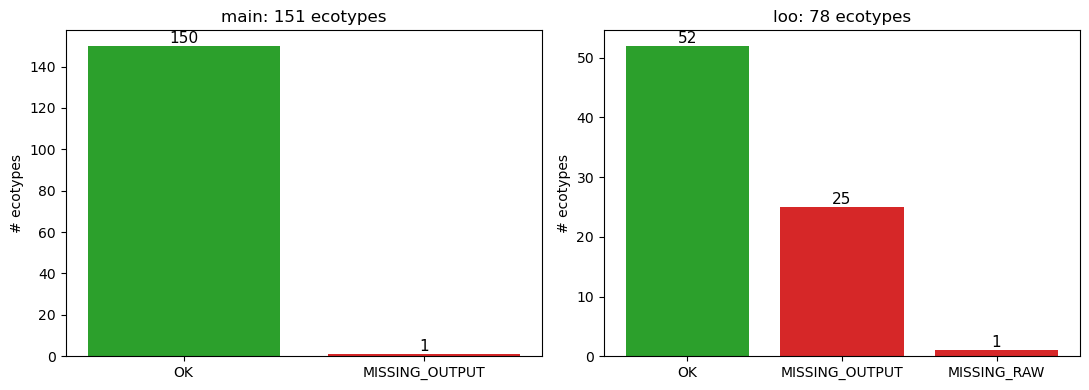


== main non-OK ==


,panel,ecotype,run,source,layout,status,files
42,main,7287,SRR1945885,ENA,PE,MISSING_OUTPUT,7287_1.dedup.fq.gz;7287_2.dedup.fq.gz



== loo non-OK ==


,panel,ecotype,run,source,layout,status,files
51,loo,8351,SRR1946001,ENA,PE,MISSING_OUTPUT,8351_1P_dedup.fq.gz;8351_2P_dedup.fq.gz
53,loo,8387,SRR1946009,ENA,PE,MISSING_OUTPUT,8387_1P_dedup.fq.gz;8387_2P_dedup.fq.gz
54,loo,9416,SRR1946088,ENA,PE,MISSING_OUTPUT,9416_1P_dedup.fq.gz;9416_2P_dedup.fq.gz
55,loo,9470,SRR1946101,ENA,PE,MISSING_OUTPUT,9470_1P_dedup.fq.gz;9470_2P_dedup.fq.gz
56,loo,9506,SRR1946106,ENA,PE,MISSING_OUTPUT,9506_1P_dedup.fq.gz;9506_2P_dedup.fq.gz
57,loo,9518,SRR1946117,ENA,PE,MISSING_OUTPUT,9518_1P_dedup.fq.gz;9518_2P_dedup.fq.gz
58,loo,9537,SRR1946136,ENA,PE,MISSING_OUTPUT,9537_1P_dedup.fq.gz;9537_2P_dedup.fq.gz
59,loo,9542,SRR1946140,ENA,PE,MISSING_OUTPUT,9542_1P_dedup.fq.gz;9542_2P_dedup.fq.gz
60,loo,9549,SRR1946147,ENA,PE,MISSING_OUTPUT,9549_1P_dedup.fq.gz;9549_2P_dedup.fq.gz
61,loo,9555,SRR1946153,ENA,PE,MISSING_OUTPUT,9555_1P_dedup.fq.gz;9555_2P_dedup.fq.gz


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, p in zip(axes, PANELS):
    s = presence[p]['status'].value_counts()
    ax.bar(s.index, s.values, color=['#2ca02c' if x=='OK' else '#d62728' for x in s.index])
    for i, v in enumerate(s.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=11)
    ax.set_title(f'{p}: {len(presence[p])} ecotypes')
    ax.set_ylabel('# ecotypes')
plt.tight_layout(); plt.show()

# Show any non-OK rows
for p in PANELS:
    bad = presence[p][presence[p].status != 'OK']
    if len(bad):
        print(f'\n== {p} non-OK ==')
        display(bad)

## 2. Clumpify duplicate rates

Distribution of `Duplicates Found` percentages across samples. Healthy short-read libraries are typically 0–30%; >50% is suspicious.

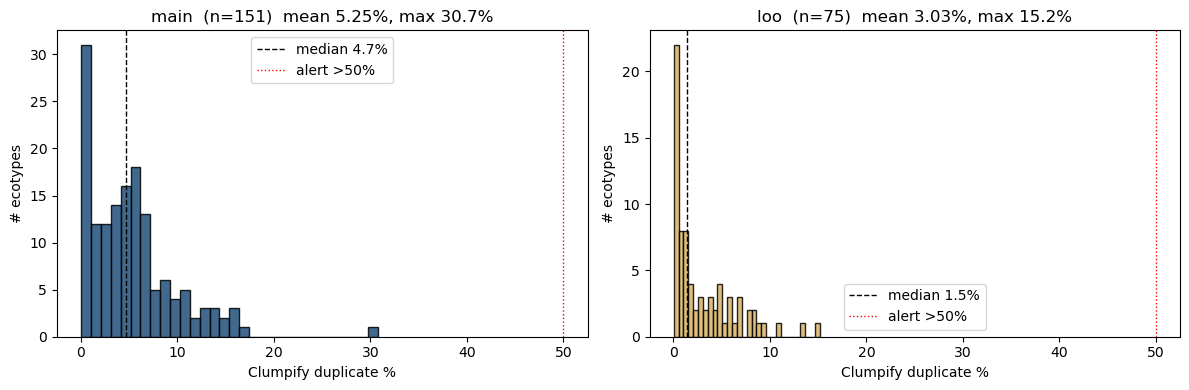


== main: top 10 by dup_pct ==
ecotype  reads_in  reads_out  dup_pct
   6216 136257636   94376352   30.737
   6243  37252068   31013178   16.748
   6074  37070682   31040680   16.266
   6040  34838332   29375894   15.679
   6013  56350178   47540700   15.633
   6108  53487294   45329586   15.252
   6073  73504686   62403252   15.103
   6177  60249828   51697440   14.195
   9944  33283540   28649273   13.924
   9966  24792319   21357751   13.853

== loo: top 10 by dup_pct ==
ecotype  reads_in  reads_out  dup_pct
   9947  31932659   27090380   15.164
   6184  74337988   64486364   13.252
  10002  58723876   52329045   10.890
  10006  32033175   28974004    9.550
   9506  47285886   43123744    8.802
   6244  37161516   34036496    8.409
   8230  48464096   44499958    8.180
   9416  54324614   50010772    7.941
   9537  33177542   30576982    7.838
   9549  42349978   39382272    7.008


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, p in zip(axes, PANELS):
    df = dup_rates[p]
    ax.hist(df.dup_pct, bins=30, color=PANEL_COLORS[p], edgecolor='k', alpha=0.85)
    ax.axvline(df.dup_pct.median(), color='k', ls='--', lw=1, label=f'median {df.dup_pct.median():.1f}%')
    ax.axvline(50, color='r', ls=':', lw=1, label='alert >50%')
    ax.set_xlabel('Clumpify duplicate %')
    ax.set_ylabel('# ecotypes')
    ax.set_title(f'{p}  (n={len(df)})  mean {df.dup_pct.mean():.2f}%, max {df.dup_pct.max():.1f}%')
    ax.legend()
plt.tight_layout(); plt.show()

# Top 10 by dup rate per panel
for p in PANELS:
    print(f'\n== {p}: top 10 by dup_pct ==')
    print(dup_rates[p].nlargest(10, 'dup_pct')[['ecotype','reads_in','reads_out','dup_pct']].to_string(index=False))

## 3. Read retention (Reads_Out / Reads_In)

Trim drops low-quality and adapter-readthrough reads; dedup drops PCR duplicates. Combined retention = `Reads Out / Reads In`. Per xwu's lighter trim params (no SLIDINGWINDOW), retention should be high — typically 80–100%.

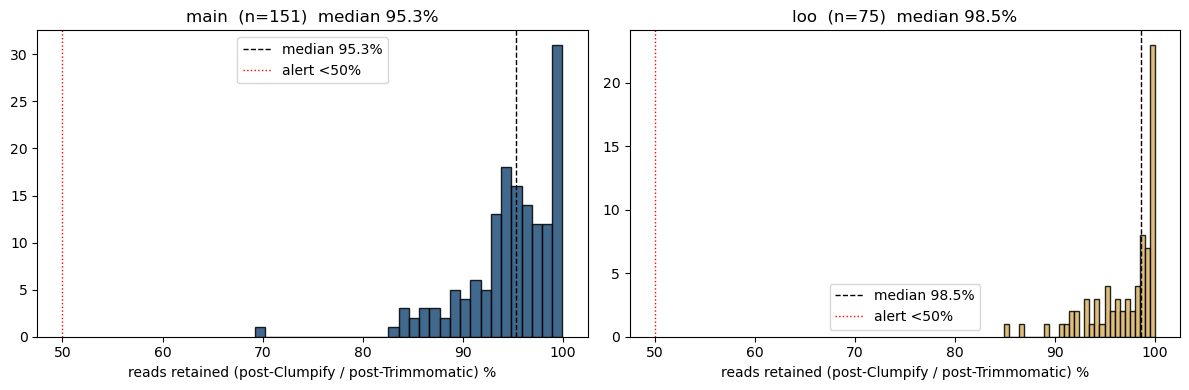

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, p in zip(axes, PANELS):
    df = dup_rates[p].copy()
    df['retain_pct'] = df.reads_out / df.reads_in * 100
    ax.hist(df.retain_pct, bins=30, color=PANEL_COLORS[p], edgecolor='k', alpha=0.85)
    ax.axvline(df.retain_pct.median(), color='k', ls='--', lw=1, label=f'median {df.retain_pct.median():.1f}%')
    ax.axvline(50, color='r', ls=':', lw=1, label='alert <50%')
    ax.set_xlabel('reads retained (post-Clumpify / post-Trimmomatic) %')
    ax.set_title(f'{p}  (n={len(df)})  median {df.retain_pct.median():.1f}%')
    ax.legend()
plt.tight_layout(); plt.show()

## 4. ENA input → preprocess delta (input shrinkage end-to-end)

`ena.read_count` is what was deposited; `Reads In` is what Trimmomatic saw; `Reads Out` is post-dedup. Material gaps between ENA and Trimmomatic-In would suggest a download or preprocess-input issue.

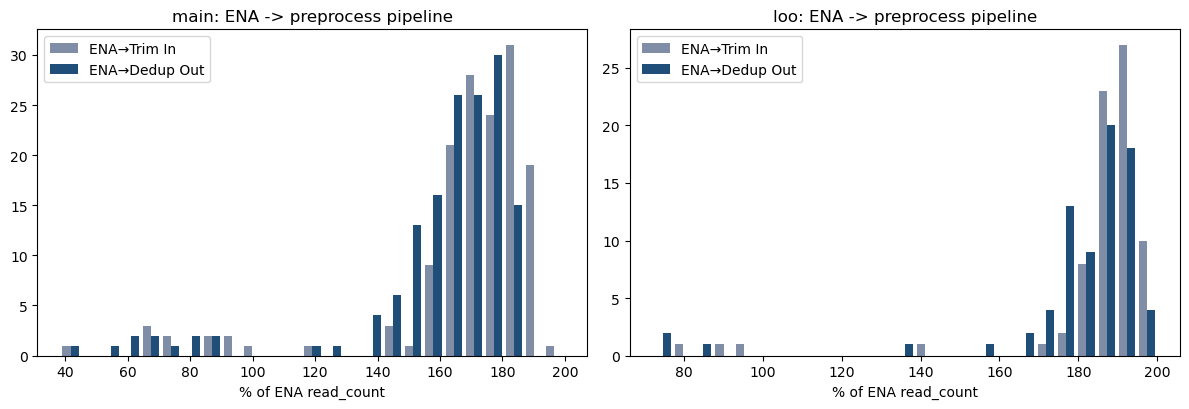


== main: ena_to_trim outside 95-110% (potential issue) ==
ecotype  read_count  reads_in  reads_out  ena_to_trim_pct library_layout
    265  27556948.0  39323406   37879854       142.698698         PAIRED
   5151  13000973.0  24090714   21864268       185.299316         PAIRED
   5165  13309856.0  24882098   23230942       186.944908         PAIRED
   5768  26289400.0  40772766   39130108       155.092037         PAIRED
   6013  33056327.0  56350178   47540700       170.467148         PAIRED
   6025  25833442.0  49024486   43872298       189.771406         PAIRED
   6040  20306156.0  34838332   29375894       171.565372         PAIRED
   6073  41324439.0  73504686   62403252       177.872193         PAIRED
   6074  22358310.0  37070682   31040680       165.802702         PAIRED
   6108  31334475.0  53487294   45329586       170.697910         PAIRED
   6177  32564591.0  60249828   51697440       185.016382         PAIRED
   6180  29418122.0  52809506   48059344       179.513519        

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, p in zip(axes, PANELS):
    df = dup_rates[p].merge(manifests[p][['ecotype','read_count']], on='ecotype', how='left')
    df['ena_to_trim_pct']  = df.reads_in  / df.read_count * 100
    df['ena_to_dedup_pct'] = df.reads_out / df.read_count * 100
    ax.hist([df.ena_to_trim_pct, df.ena_to_dedup_pct], bins=25,
            label=['ENA→Trim In','ENA→Dedup Out'], color=['#7f8da6','#1f4e79'])
    ax.set_xlabel('% of ENA read_count')
    ax.set_title(f'{p}: ENA -> preprocess pipeline')
    ax.legend()
plt.tight_layout(); plt.show()

for p in PANELS:
    df = dup_rates[p].merge(manifests[p][['ecotype','read_count','library_layout']], on='ecotype', how='left')
    df['ena_to_trim_pct']  = df.reads_in  / df.read_count * 100
    suspect = df[(df.ena_to_trim_pct < 95) | (df.ena_to_trim_pct > 110)]
    if len(suspect):
        print(f'\n== {p}: ena_to_trim outside 95-110% (potential issue) ==')
        print(suspect[['ecotype','read_count','reads_in','reads_out','ena_to_trim_pct','library_layout']].to_string(index=False))

## 5. Per-file QC results (gzip integrity, R1/R2 parity, coverage, read length)

Cell below loads `qc_results/` per-task TSVs (one per ecotype, written by `qc_one.sh` SLURM array). Run the array via:

```bash
PANEL=main sbatch --array=1-150%16 preprocess_qc/scripts/qc_one.sh
PANEL=loo  sbatch --array=1-52%16  preprocess_qc/scripts/qc_one.sh
```

After it finishes:

Loaded 204 QC rows

gzip integrity counts:
       gz_r1_BAD  gz_r2_BAD
panel                      
loo            0          0
main           0          0

PE pair parity counts:
panel  pair_ok
loo    yes         51
main   yes        142
Name: count, dtype: int64

Coverage estimates:
       count       mean        std   min     25%    50%    75%     max
panel                                                                 
loo     53.0  23.940755  13.427868  9.88  15.100  21.22  27.26   83.81
main   151.0  21.778146  11.822068  1.25  15.225  19.09  25.06  103.87


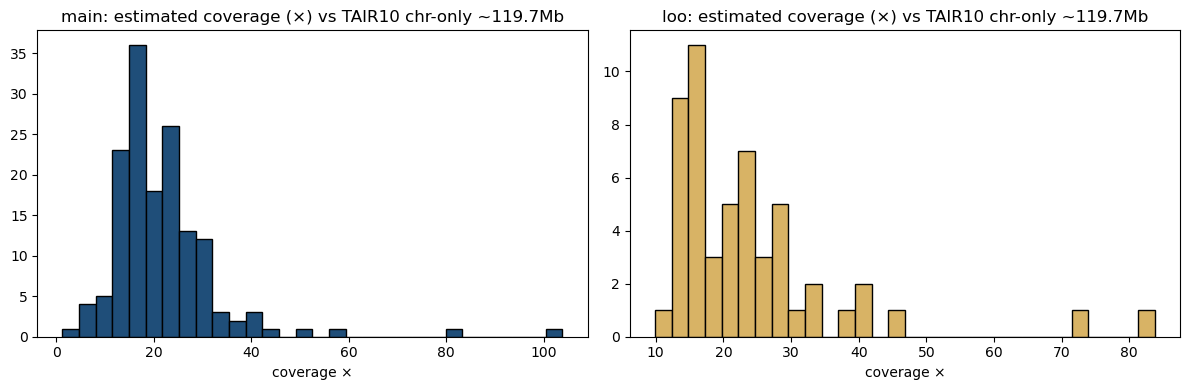

In [6]:
qc_dir = OUT/'qc_results'
if not qc_dir.exists() or not any(qc_dir.iterdir()):
    print('qc_results/ is empty — submit the qc_one.sh array first.')
else:
    qc_all = pd.concat([pd.read_csv(p, sep='\t') for p in qc_dir.glob('*.tsv')], ignore_index=True)
    print(f'Loaded {len(qc_all)} QC rows')
    print('\ngzip integrity counts:')
    print(qc_all.groupby('panel')[['gz_r1','gz_r2']].apply(lambda d: pd.Series({'gz_r1_BAD':(d.gz_r1=='BAD').sum(),'gz_r2_BAD':(d.gz_r2=='BAD').sum()})))
    print('\nPE pair parity counts:')
    pe = qc_all[qc_all.layout=='PE']
    print(pe.groupby('panel')['pair_ok'].value_counts())
    print('\nCoverage estimates:')
    print(qc_all.groupby('panel')['cov_est'].describe())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, p in zip(axes, PANELS):
        sub = qc_all[qc_all.panel==p]
        ax.hist(sub.cov_est, bins=30, color=PANEL_COLORS[p], edgecolor='k')
        ax.set_title(f'{p}: estimated coverage (×) vs TAIR10 chr-only ~119.7Mb')
        ax.set_xlabel('coverage ×')
    plt.tight_layout(); plt.show()

## 6. Headline summary

In [7]:
for p in PANELS:
    pres = presence[p]
    dup = dup_rates[p]
    print(f'== {p} ==')
    print(f'  ecotypes:        {len(pres)}')
    print(f'  presence OK:     {(pres.status=="OK").sum()}/{len(pres)}')
    print(f'  dup rate:        median {dup.dup_pct.median():.1f}%  mean {dup.dup_pct.mean():.2f}%  max {dup.dup_pct.max():.1f}%')
    retain = (dup.reads_out/dup.reads_in*100)
    print(f'  retention:       median {retain.median():.1f}%  min {retain.min():.1f}%')
    print()

== main ==
  ecotypes:        151
  presence OK:     150/151
  dup rate:        median 4.7%  mean 5.25%  max 30.7%
  retention:       median 95.3%  min 69.3%

== loo ==
  ecotypes:        78
  presence OK:     52/78
  dup rate:        median 1.5%  mean 3.03%  max 15.2%
  retention:       median 98.5%  min 84.8%

